## User Story 1: Predictions

I see a plot showing reconstructions from FBP, MLE, MAP, U-Net, U-Net ensemble, conditional diffusion
three datasets and number of angles and number of used angles 10, 30, 100, 200 together with the corresponding ground truth images, all on the same $128 \times 128$ resolution.
In total that is $7 \cdot 3 \cdot 4 = 84$ images. I can see $84$ images, divided into $4$ groups (4 number of angles) of $3 \cdot 7$ images (three datasets and four reconstruction methods plus ground truth). The previous plots correspond to fixed total intensity value $10^7$.
The following cell shows the effect of varying the total intensity but keeping the number of angles fixed at 30.
There are three rows, corresponding to total intensities $10^4, 10^6, 10^9$, and 7 columns, corresponding to the different predictors plus the ground truth image. 

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import lovely_tensors as lt
import matplotlib.pyplot as plt
import torch

from uqct.training.unet import N_BINS_HR
from uqct.datasets.utils import get_dataset

lt.monkey_patch()
plt.style.use('ggplot') 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_float32_matmul_precision("high")
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
ds_composite_train, ds_composite_test = get_dataset("composite", True)
ds_lung_train, ds_lung_test = get_dataset("lung", True)
ds_lamino_train, ds_lamino_test = get_dataset("lamino", True)

In [2]:
from tqdm.auto import tqdm

def check_min_max(name, ds):
    print(f"{name.upper().center(50, '-')}")
    mn, mx = float('inf'), float('-inf')
    for x in (pbar := tqdm(ds)):
        mn, mx = min(mn, x.min()), max(mx, x.max())
        pbar.set_postfix(dict(min=mn, max=mx))
    print(f"Min: {mn}, Max: {mx}\n")

In [3]:
check_min_max("lung-train", ds_lung_train)
check_min_max("lung-test", ds_lung_test)
check_min_max("composite-train", ds_composite_train)
check_min_max("composite-test", ds_composite_test)
check_min_max("lamino-train", ds_lamino_train)
check_min_max("lamino-test", ds_lamino_test)

--------------------LUNG-TRAIN--------------------


  0%|          | 0/34048 [00:00<?, ?it/s]

Min: 0.0, Max: 1.000000238418579

--------------------LUNG-TEST---------------------


  0%|          | 0/1792 [00:00<?, ?it/s]

Min: 0.0, Max: 1.000000238418579

-----------------COMPOSITE-TRAIN------------------


...

Min: 0.0, Max: 0.9756869673728943

-------------------LAMINO-TRAIN-------------------


  0%|          | 0/9850 [00:00<?, ?it/s]

Min: 0.0, Max: 1.0000149011611938

-------------------LAMINO-TEST--------------------


  0%|          | 0/518 [00:00<?, ?it/s]

Min: 0.0, Max: 0.9615949988365173



In [ ]:
from tqdm.auto import tqdm
ds = ds_lung_train
mn, mx = float('inf'), float('-inf')
for x in (pbar := tqdm(ds)):
    mn, mx = min(mn, x.min()), max(mx, x.max())
    pbar.set_postfix(dict(min=mn, max=mx))
print(f"Min: {mn}, Max: {mx}")

0 tensor[1, 256, 256] n=65536 (0.2Mb) x∈[0., 0.520] μ=0.143 σ=0.116
1 tensor[1, 256, 256] n=65536 (0.2Mb) x∈[0., 0.597] μ=0.207 σ=0.120
2 tensor[1, 256, 256] n=65536 (0.2Mb) x∈[0., 0.570] μ=0.410 σ=0.222


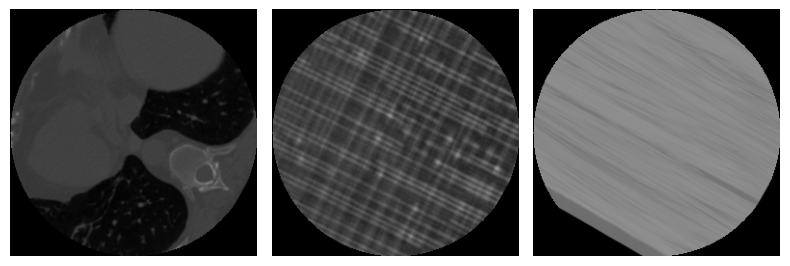

In [5]:
datasets = {name: get_dataset(name, True)[1] for name in ['lung', 'lamino', 'composite']} # type: ignore
fig, axes = plt.subplots(1, len(datasets), figsize=(8, 8*len(datasets)))
imshow_params = dict(cmap='grey', vmin=0, vmax=1)
for i, (ax, ds) in enumerate(zip(axes, datasets.values())):
    print(i, ds[5])
    ax.imshow(ds[5].reshape(N_BINS_HR, N_BINS_HR), **imshow_params)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [2]:
import numpy as np

from uqct.datasets.utils import get_dataset
from uqct.training.unet import N_ANGLES
from uqct.ct import sample_observations, Experiment

dataset_names = list(datasets.keys())
schedule = torch.tensor([1, 30, 100, 200], device=device)
methods = ['fbp', 'mle', 'map', 'unet', 'unet-ensemble', 'diffusion']
total_intensity = 1e9

angles = torch.from_numpy(np.linspace(0, 180, N_ANGLES, endpoint=False)).to(device)

experiments = dict()
gt_images = dict()
for ds_name, ds in datasets.items():
    intensities = torch.tensor(total_intensity, device=device)
    intensities = intensities.view(1, 1, 1, 1).expand(1, -1, N_ANGLES, -1) / (
        N_ANGLES * N_BINS_HR
    )
    gt_image = ds[0].to(device)
    gt_images[ds_name] = gt_image
    counts = sample_observations(gt_image, intensities, angles)
    intensities_lr = intensities * 2
    exp = Experiment(counts, intensities_lr, angles, True)
    experiments[ds_name] = exp
for ds_name, exp in experiments.items():
    print(f"{ds_name.upper()}:")
    print(exp, "\n")

LUNG:
Experiment(sparse=True, intensities=tensor[1, 1, 200, 1] x∈[3.906e+04, 3.906e+04] μ=3.906e+04 σ=0. cuda:0, counts=tensor[1, 1, 200, 128] n=25600 (100Kb) x∈[1.231e+04, 3.945e+04] μ=2.237e+04 σ=5.586e+03 cuda:0, angles=tensor[200] f64 1.6Kb x∈[0., 179.100] μ=89.550 σ=52.091 cuda:0) 

LAMINO:
Experiment(sparse=True, intensities=tensor[1, 1, 200, 1] x∈[3.906e+04, 3.906e+04] μ=3.906e+04 σ=0. cuda:0, counts=tensor[1, 1, 200, 128] n=25600 (100Kb) x∈[4.177e+03, 3.673e+04] μ=1.331e+04 σ=5.327e+03 cuda:0, angles=tensor[200] f64 1.6Kb x∈[0., 179.100] μ=89.550 σ=52.091 cuda:0) 

COMPOSITE:
Experiment(sparse=True, intensities=tensor[1, 1, 200, 1] x∈[3.906e+04, 3.906e+04] μ=3.906e+04 σ=0. cuda:0, counts=tensor[1, 1, 200, 128] n=25600 (100Kb) x∈[2.048e+03, 3.983e+04] μ=1.033e+04 σ=8.246e+03 cuda:0, angles=tensor[200] f64 1.6Kb x∈[0., 179.100] μ=89.550 σ=52.091 cuda:0) 



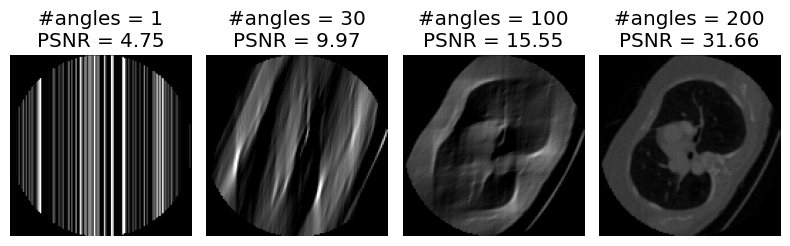

In [3]:
from uqct.ct import prepare_inputs_from_experiment
from uqct.training.unet import N_BINS_LR
from uqct.metrics import b_PSNR
from torch.nn.functional import interpolate

def get_fbp_pred(experiment: Experiment, schedule: torch.Tensor) -> torch.Tensor:
    """Returns a (N, len(schedule), N_BINS_LR, N_BINS_LR) tensor."""
    fbps, _, _ = prepare_inputs_from_experiment(experiment, schedule)
    return fbps.reshape(-1, len(schedule), N_BINS_LR, N_BINS_LR)


def plot_preds(preds: torch.Tensor, image: torch.Tensor) -> None:
    preds = preds.reshape(-1, N_BINS_LR, N_BINS_LR)
    image = interpolate(
        image.unsqueeze(0), size=(N_BINS_LR, N_BINS_LR), mode='area'
    ).squeeze()
    image = image.expand(len(preds), -1, -1)
    psnrs = b_PSNR(image, preds)
    fig, axes = plt.subplots(1, len(schedule), figsize=(8, len(schedule)*8))
    for i in range(len(schedule)):
        axes[i].imshow(preds[i].cpu(), **imshow_params)
        axes[i].axis("off")
        axes[i].set_title(f"#angles = {schedule[i]}\nPSNR = {psnrs[i].item():.2f}")
    plt.tight_layout()
    plt.show()

fbps = get_fbp_pred(experiments['lung'], schedule)
plot_preds(fbps, gt_images['lung'])


  0%|          | 0/20000 [00:00<?, ?it/s]

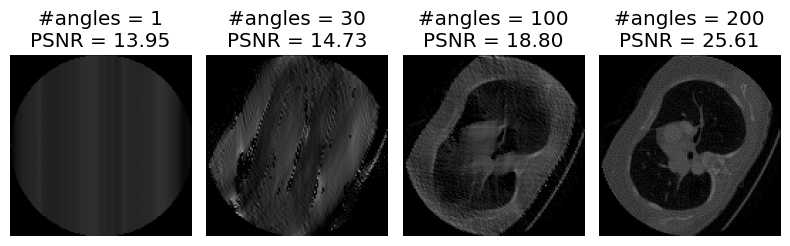

In [4]:
from typing import Literal
import torch

from uqct.models.diffusion import get_guidance_loss_fn, guide
from uqct.ct import lr_from_experiment, Experiment

def get_iterative_preds(
    experiment: Experiment, 
    schedule: torch.Tensor, 
    kind: Literal['mle', 'map'] = 'mle',
    max_steps: int = 20000, 
    patience: int = 50,
    ) -> torch.Tensor:
    fbps =  get_fbp_pred(experiment, schedule).to(device)
    fbps_n1p1 = ((fbps - 0.5) / 0.5).clip(-1, 1)

    mle_loss_fct = get_guidance_loss_fn(experiment, schedule)

    def map_loss_fct(image: torch.Tensor):
        """
        log(N(x; 0, I)) ~ ||x||^2
        """
        return mle_loss_fct(image) + (image**2).mean()

    loss_fct = mle_loss_fct if kind == 'mle' else map_loss_fct
    lr = lr_from_experiment(experiment) / 10
    out = (guide(fbps_n1p1, loss_fct, max_steps, lr, patience=patience, verbose=True) * 0.5 + 0.5).clip(0, 1)
    return out

mles = get_iterative_preds(experiments['lung'], schedule, kind='mle', patience=25)
plot_preds(mles, gt_images['lung'])

  0%|          | 0/20000 [00:00<?, ?it/s]

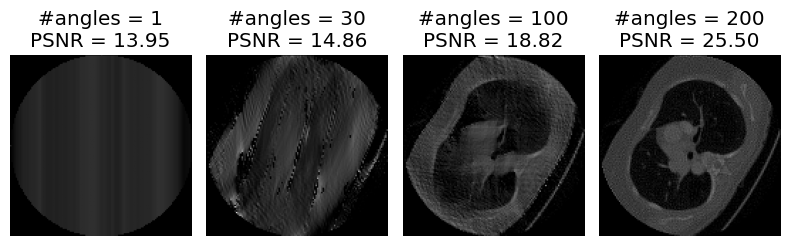

In [5]:
maps = get_iterative_preds(experiments['lung'], schedule, kind='map', patience=25)
plot_preds(maps, gt_images['lung'])

In [ ]:
from uqct.models.unet import FBPUNet

unet_lung_0 = FBPUNet("lung", member=0, sparse=True)
# 7847 MiB -> 8553 MiB: 706 MiB


# def get_unet_preds(experiment: Experiment, schedule: torch.Tensor) -> torch.Tensor:
#     return unet_lung_0.predict(experiment, schedule)

# preds = get_unet_preds(experiments['lung'], schedule)
# plot_preds(preds, gt_images['lung'])

In [13]:
unet_lung_0.to("cpu", torch.float16)

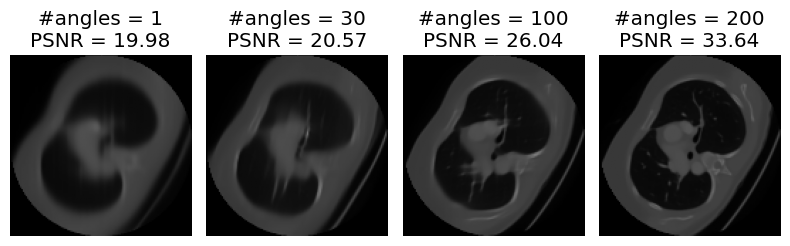

In [ ]:
from uqct.models.unet import FBPUNetEnsemble

unet_ensemble_lung = FBPUNetEnsemble("lung", sparse=True)

def get_unet_ensemble_preds(experiment: Experiment, schedule: torch.Tensor) -> torch.Tensor:
    return unet_ensemble_lung.predict(experiment, schedule, aggregate="mean")

preds = get_unet_ensemble_preds(experiments['lung'], schedule)
plot_preds(preds, gt_images['lung'])

()

In [ ]:

# def lr2psnr(dataset: DatasetName, sparse: bool, cond: bool, total_intensity: float, lr: float) -> torch.Tensor:
#     """Returns the PSNR of generated Diffusion samples."""

#     n_gt = min(10 if sparse else 3, len(test_set))

#     gt = torch.stack([test_set[i] for i in range(n_gt)], dim=0).to(device)

#     angles = torch.from_numpy(np.linspace(0, 180, n_angles, endpoint=False)).to(device)
#     n_detectors_hr = gt.shape[-1]
#     intensities = torch.tensor(total_intensity, device=device)
#     if sparse:
#         intensities = intensities.view(1, 1, 1, 1).expand(n_gt, -1, n_angles, -1) / (
#             n_angles * n_detectors_hr
#         )
#         schedule = torch.tensor([1, 50, 100, 150, 200])
#     else:
#         n_rounds = 1
#         intensities = intensities.view(1, 1, 1, 1).expand(
#             n_gt, n_rounds, n_angles, -1
#         ) / (n_angles * n_detectors_hr * n_rounds)
#         schedule = None
#     counts = sample_observations(gt, intensities, angles)
#     intensities_lr = intensities * 2
#     experiment = Experiment(counts, intensities_lr, angles, sparse)
#     diffusion = Diffusion(
#         dataset,
#         num_steps=100,
#         sgd_steps=10,
#         lr=lr,
#         batch_size=16,
#         cond=cond,
#         verbose=False,
#     )

#     guidance_loss_fn = get_guidance_loss_fn(experiment, schedule)
#     sample = diffusion.sample(experiment, 1 if experiment.sparse else 3, schedule, guidance_loss_fn)
#     gt_lr = F.interpolate(gt, (128, 128), mode="area")
#     gt_lr = gt_lr.unsqueeze(1).unsqueeze(1).expand(-1, -1, sample.shape[2], -1, -1, -1)
#     return b_PSNR(gt_lr, sample)

## User Story 2: Mean or Median better?

I can see a box plot showing the distribution of PSNRs differences between the mean and median reconstruction for MLE, MAP, U-Net ensemble and conditional diffusion reconstructions. On the horizontal axis are the different reconstruction methods.
Textual outputs state that mean or median reconstruction works better on average (with a p-value).

## User Story 3: Mixing > Mean / Median

I can see a single plot showing the average difference (across runs) of confidence coefficients between confidence sequences with and without mixing.
The individual runs are faded and colored according to whether they are aggregated or mixing runs.
A non-faded line with corresponding color is shown as well, it is clear that mixing outperforms aggregation based sequences. 

## User Story 4: Rotations

For the lung dataset I can an example ground truth image.
The next cell output shows a plot of the 

$$
L_{t}(\theta^\ast), \beta_{t}(\delta), L_{t}(\theta_{rot})
$$ 

against $t$. A dashed green vertical line indicates the first time $L_t(\theta_{rot})$ crosses 
$\beta_{t}(\delta)$. A dashed purple vertical line indicates the first time $L_t(\theta^\ast)$ crosses $\beta_{t}(\delta)$. 

I can see print statements that say that the rotated image is not in the confidence set after some time.
I can also see a print statement that says the true image is in the confidence set.

## User Story 5: Early Stopping

I can see a composite data set image.
I can also see a plot showing $\ell_2$ maximizer distance and PSNR against time for this image. 
In the same plot, a vertical line and annotation indicates at which time step PSNR reaches 30 dB.
Below that, another plot shows 15 runs (3 datasets and 5 different images from each) with again PSNR and $\ell_2$ plotted against time. This time, the different lines are transparent.
The next cell shows the regression of PSNR on $\ell_2$ distance. 

## User Story 6: Deep Learning Yields Tighter Confidence Sets

I can see a plot showing average pixel-wise confidence interval lengths

$$
\tau = \frac{1}{HW} \sum_{i, j \in [H] \times [W]} \overline{u}_{ij} - \underline{u}_{ij}
$$

against time for all three datasets, seperately and pooled, for 10 data points from each dataset and 6 predictors.

## User Story 7: Hallucination Detection (Optional)

I can see some conditional diffusion images that are clearly not very similar to the ground truth image and some which are. 
The confidence sequence detects them automatically. 

## User Story 8: Distance-based Confidence Images

I can see a $3 \times 3$ grid with a confidence image in each cell. They correspond to the same ground truth image but different combinations of total intensity (low $10^4$, medium $10^6$, high $10^9$) and number of angles (low $10$, medium $90$ and high $200$). 
Another plot regresses PSNR on confidence, defined as
$$
    \xi^\text{dist} = 1 - \frac{1}{WH} \sum_{i, j \in [W] \times [H]} \overline{u}^\text{dist}_{ij} - \underline{u}^\text{dist}_{ij}.
$$